# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [101]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [102]:
data = pd.read_csv('./data/cleaned_aviation_data.csv', index_col=0, encoding='latin1')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [103]:
small_plane_data = data[data['Total.Passengers'] <= 20]
large_plane_data = data[data['Total.Passengers'] > 20]

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

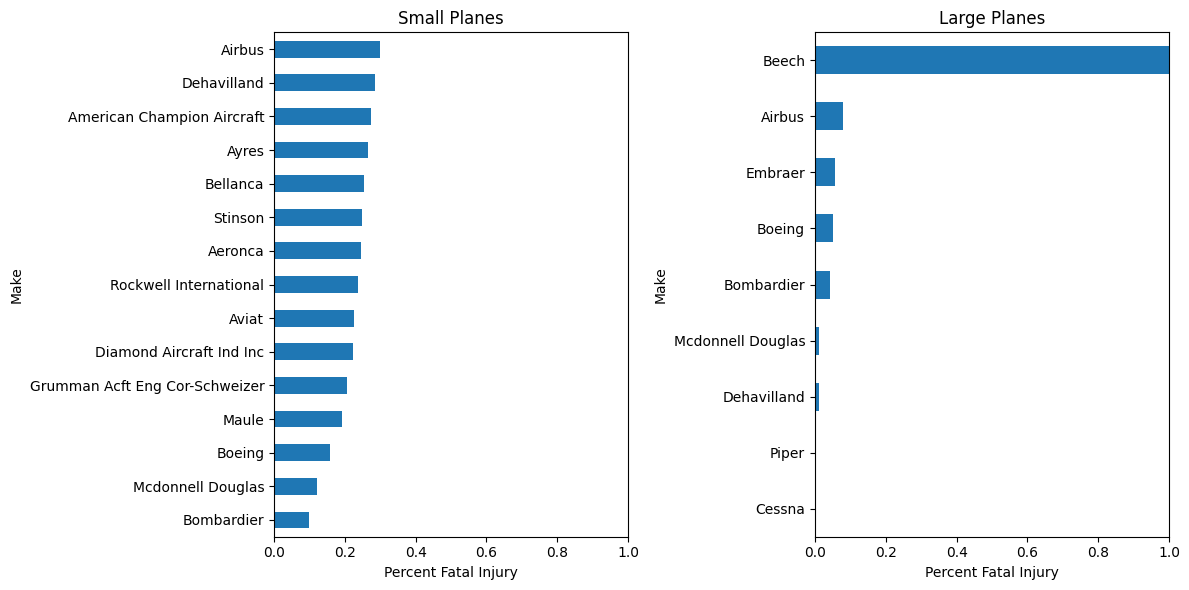

In [104]:
small_make = small_plane_data.groupby('Make')['Percent.Serious.Or.Fatal.Injury'].mean().sort_values(ascending=True).head(15)
large_make = large_plane_data.groupby('Make')['Percent.Serious.Or.Fatal.Injury'].mean().sort_values(ascending=True).head(15)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Small planes plot
small_make.plot.barh(ax=axes[0])
axes[0].set_title('Small Planes')
axes[0].set_xlabel('Percent Fatal Injury')

# Large planes plot
large_make.plot.barh(ax=axes[1])
axes[1].set_title('Large Planes')
axes[1].set_xlabel('Percent Fatal Injury')
max_val = max(small_make.max(), large_make.max())

axes[0].set_xlim(0, max_val)
axes[1].set_xlim(0, max_val)
plt.tight_layout()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

Text(0, 0.5, 'Percent Fatal Injury')

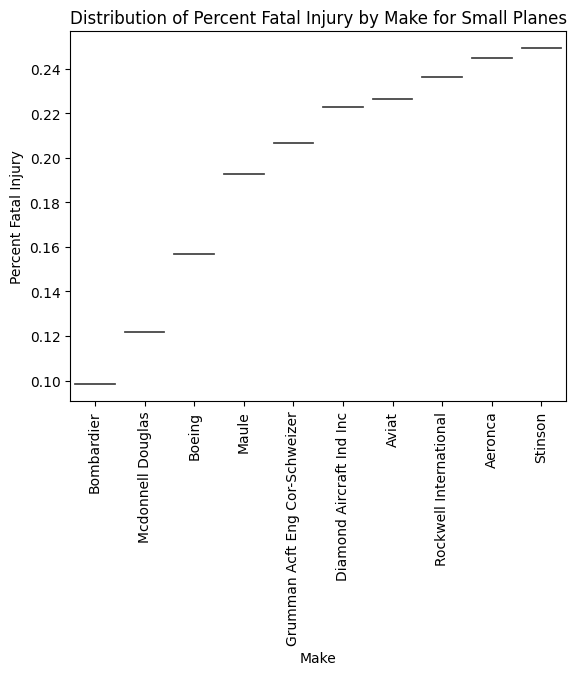

In [105]:
small_make = small_plane_data.groupby('Make')['Percent.Serious.Or.Fatal.Injury'].mean().sort_values(ascending=True).head(10)

sns.violinplot(x=small_make.index, y=small_make.values)
plt.xticks(rotation=90)
plt.title('Distribution of Percent Fatal Injury by Make for Small Planes')
plt.ylabel('Percent Fatal Injury')

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

Text(0, 0.5, 'Percent Fatal Injury')

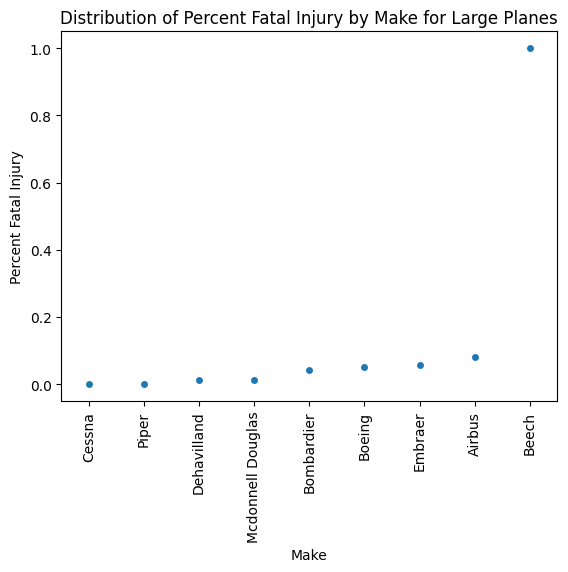

In [106]:
large_make = large_plane_data.groupby('Make')['Percent.Serious.Or.Fatal.Injury'].mean().sort_values(ascending=True).head(10)
sns.stripplot(x=large_make.index, y=large_make.values)
plt.xticks(rotation=90)
plt.title('Distribution of Percent Fatal Injury by Make for Large Planes')
plt.ylabel('Percent Fatal Injury')

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

count    15.000000
mean      0.038035
std       0.017411
min       0.017241
25%       0.025994
50%       0.039216
75%       0.041301
max       0.075758
Name: Destroyed, dtype: float64
count    9.000000
mean     0.143254
std      0.322922
min      0.000000
25%      0.000000
50%      0.041152
75%      0.070175
max      1.000000
Name: Destroyed, dtype: float64
               Investigation.Type Accident.Number  Event.Date  \
Event.Id                                                        
20101116X32303           Accident      DCA11WA008  2010-11-05   

                         Location   Country Latitude Longitude  \
Event.Id                                                         
20101116X32303  Karachi, Pakistan  Pakistan      NaN       NaN   

               Injury.Severity Aircraft.damage Aircraft.Category  ...  \
Event.Id                                                          ...   
20101116X32303           Fatal       Destroyed          Airplane  ...   

               Total.Mino

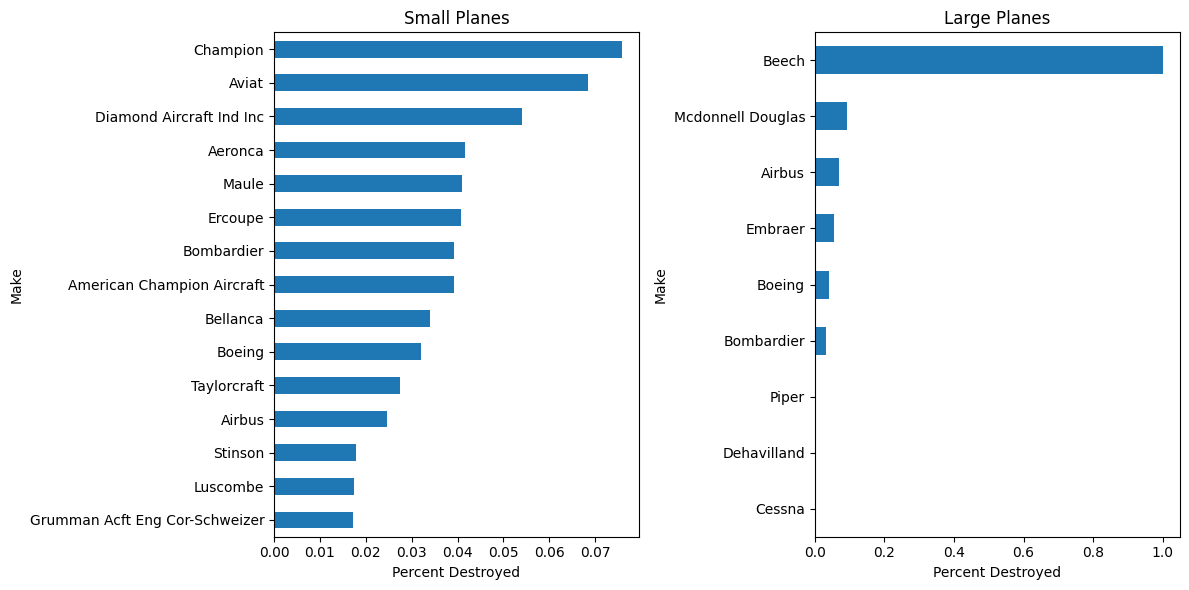

In [107]:
small_make_dest = small_plane_data.groupby('Make')['Destroyed'].mean().sort_values(ascending=True).head(15)
large_make_dest = large_plane_data.groupby('Make')['Destroyed'].mean().sort_values(ascending=True).head(15)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

small_make_dest.plot.barh(ax=axes[0])
axes[0].set_title('Small Planes')
axes[0].set_xlabel('Percent Destroyed')

# Large planes plot
large_make_dest.plot.barh(ax=axes[1])
axes[1].set_title('Large Planes')
axes[1].set_xlabel('Percent Destroyed')

plt.tight_layout()

print(small_make_dest.describe())
print(large_make_dest.describe())
print(large_plane_data[large_plane_data['Make'] == 'Beech'])

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

It seems like in general small planes have more data so their stats are less extreme. You can see that there was a Beech large plane crash that was destroyed with 100% fatality rate. You can also see in the graphs with 15 makes that there were a total of 11 different makes for large planes even though the cutoff was 15 meaning we only had 11 makes in our data. 

The mean for the small planes was around 3% while the mean for the large planes was around 12% for the lowest 15 destruction rates by make. You can also see that the 50% quartile for large makes is 4% showing that the Beech accident heavily skews the data. The standard deviation for the Large planes is also much larger at .29 compared to that of .010 for the small planes, showing the dispersion is much greater. 

When we reduce the number of makes to 10, the data apears to be much similar between large and small planes for fatality rates. The max for large planes reduces to 7% fatality rate while the max for small planes is around 11% for the lowest 10 rates. 

Based on this data it seems like Bombabier and Boeing may be some of the safer makes, as they are both in the top 15 lowest for fatality rate, and destruction rate for both small and large planes. However, not all manufactors make both small and large planes so this is a bit misleading. 

Also based on the data you could want to avoid flying Beech or recommend Beech improves their safety, however the sample size is quite low at n=1.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Text(0, 0.5, 'Make')

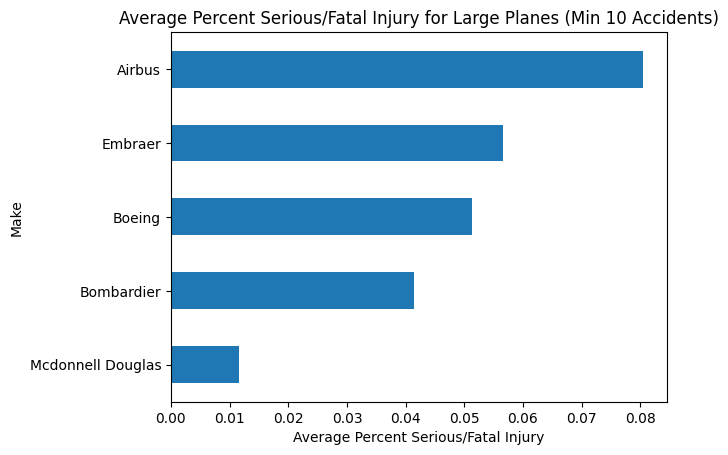

In [108]:
stats = large_plane_data.groupby('Make')['Percent.Serious.Or.Fatal.Injury'].agg(['mean', 'count'])
filtered_stats = stats[stats['count'] >= 10]

large_results = filtered_stats['mean'].sort_values(ascending=True).head(10)

large_results.plot.barh()
plt.title('Average Percent Serious/Fatal Injury for Large Planes (Min 10 Accidents)')
plt.xlabel('Average Percent Serious/Fatal Injury')
plt.ylabel('Make')

Text(0, 0.5, 'Percent Serious/Fatal Injury')

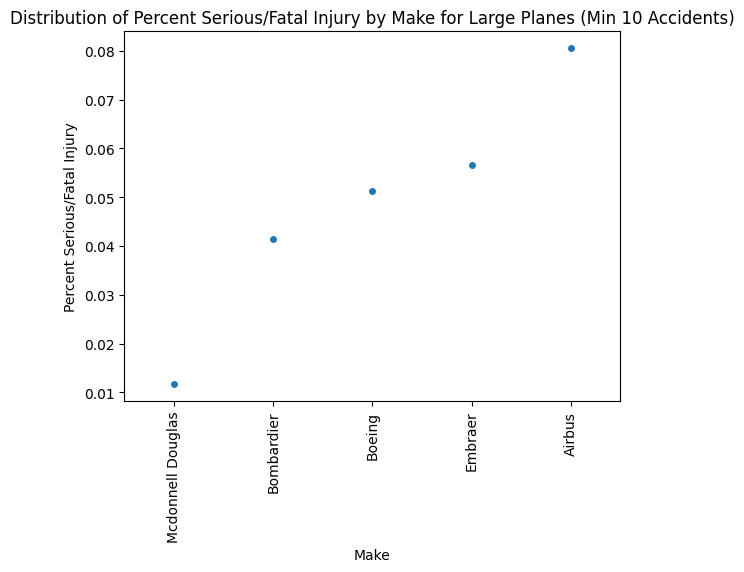

In [109]:
sns.stripplot(x=large_results.index, y=large_results.values)
plt.xticks(rotation=90)
plt.title('Distribution of Percent Serious/Fatal Injury by Make for Large Planes (Min 10 Accidents)')
plt.ylabel('Percent Serious/Fatal Injury')

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Text(0, 0.5, 'Make')

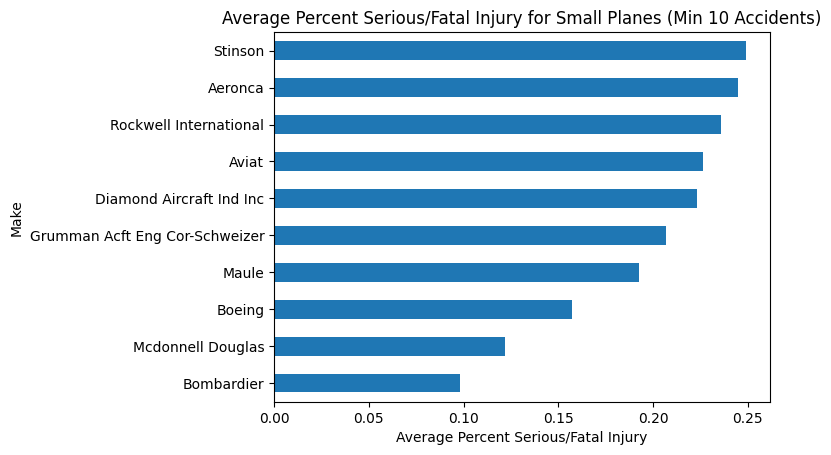

In [110]:
stats = small_plane_data.groupby('Make')['Percent.Serious.Or.Fatal.Injury'].agg(['mean', 'count'])
filtered_stats = stats[stats['count'] >= 10]

small_results = filtered_stats['mean'].sort_values(ascending=True).head(10)

small_results.plot.barh()
plt.title('Average Percent Serious/Fatal Injury for Small Planes (Min 10 Accidents)')
plt.xlabel('Average Percent Serious/Fatal Injury')
plt.ylabel('Make')

Text(0, 0.5, 'Percent Serious/Fatal Injury')

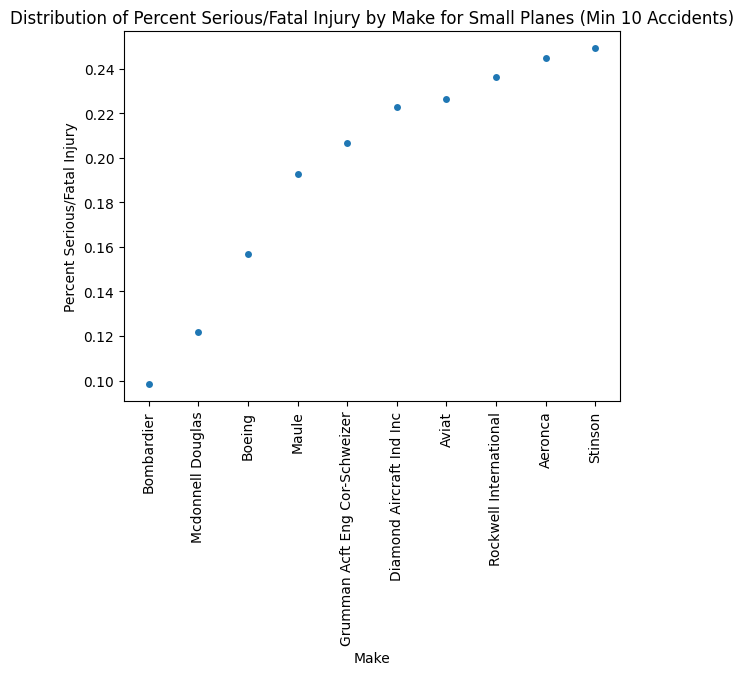

In [111]:
sns.stripplot(x=small_results.index, y=small_results.values)
plt.xticks(rotation=90)
plt.title('Distribution of Percent Serious/Fatal Injury by Make for Small Planes (Min 10 Accidents)')
plt.ylabel('Percent Serious/Fatal Injury')

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Once we ensure adequete sample sizes by setting a minimum of 10 per make, we can see that larger airplanes are much safer than smaller ones it terms of percent fatal/serious injuries. The 10 safest for small airplanes range from 10% to 25% serious injury/fatality rate compared to the 1% to 8% range for the 5 large airplane makes that had enough data for the analysis. 

There is also a decent amount of variance between the safest and least safe of the large planes in the plots, with the same being true for small planes. Airbus has an eight times higher percent of serious/fatal injuires compared to Mcdonnell Douglas. Similary Stinson has a 2.5 times higher rate of serious/fatal injuries than Bombardier. This shows that even if larger planes are safer, it is still important to differeniate between the makes if you want to maximize safety. 

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

### Engine Types

The first variable I will look into is how engine type influences damage/injuries.

count    5.000000
mean     0.265631
std      0.113031
min      0.089039
25%      0.233463
50%      0.291612
75%      0.329584
max      0.384456
Name: mean, dtype: float64

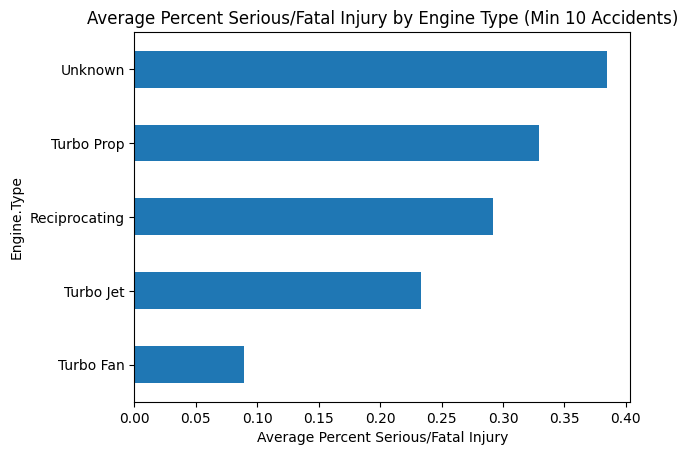

In [112]:
stats = data.groupby('Engine.Type')['Percent.Serious.Or.Fatal.Injury'].agg(['mean', 'count'])
filtered_stats = stats[stats['count'] >= 10]
engine_results = filtered_stats['mean'].sort_values(ascending=True).head(10)
engine_results.plot.barh()
plt.title('Average Percent Serious/Fatal Injury by Engine Type (Min 10 Accidents)')
plt.xlabel('Average Percent Serious/Fatal Injury')

engine_results.describe()

count    6.000000
mean     0.123224
std      0.099713
min      0.000000
25%      0.057022
50%      0.116616
75%      0.175682
max      0.273585
Name: mean, dtype: float64

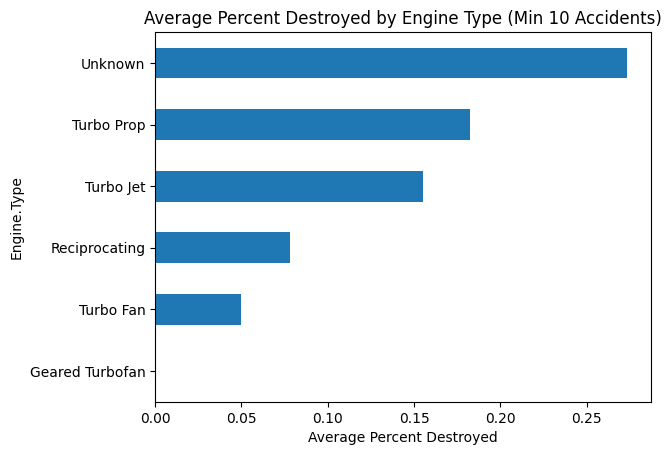

In [113]:
stats = data.groupby('Engine.Type')['Destroyed'].agg(['mean', 'count'])
filtered_stats = stats[stats['count'] >= 10]
engine_results = filtered_stats['mean'].sort_values(ascending=True).head(10)
engine_results.plot.barh()
plt.title('Average Percent Destroyed by Engine Type (Min 10 Accidents)')
plt.xlabel('Average Percent Destroyed')

engine_results.describe()

As you can see the different engine types seem consistent across damage and injury for the most part. This makes sense because destroyed planes will tend to have people being serious injured or die. 

The top category is unknown, telling us the most common damage/injury happens with an unknown engine type. This could be due to planes being unrecoverable, failure to identify engines due to damage, or just faulty data collection. 

Aside from this we can see that Turbo props are the next most dangerous engine type with a mean of ~33% fatal or serious injuries and ~18% of planes destroyed. We can also see that Turbo fans seem to be the safest engine type with enough data to be in the two categories. They have a destruction mean of ~5% and ~9% serious or fatal injury rate. 

One interesting thing is that reciprocating engines have a lower destruction average than turbo jets by ~8% , however they have around a ~5% higher mean for injury rates. This could tell us that although planes with turbo jets are more likely to be destroyed than ones with reciprocating engines they are safer for passengers riding in them.  

### Weather Condition
The second variable I will investigate is how the weather affects accidents


count    3.000000
mean     0.468316
std      0.193852
min      0.262643
25%      0.378648
50%      0.494652
75%      0.571153
max      0.647654
Name: mean, dtype: float64

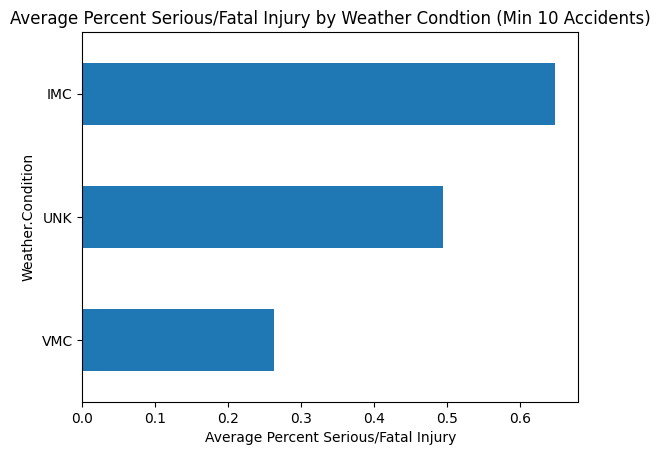

In [114]:
stats = data.groupby('Weather.Condition')['Percent.Serious.Or.Fatal.Injury'].agg(['mean', 'count'])
filtered_stats = stats[stats['count'] >= 10]
weather_results = filtered_stats['mean'].sort_values(ascending=True).head(10)
weather_results.plot.barh()
plt.title('Average Percent Serious/Fatal Injury by Weather Condtion (Min 10 Accidents)')
plt.xlabel('Average Percent Serious/Fatal Injury')

weather_results.describe()

count    3.000000
mean     0.227430
std      0.142051
min      0.070864
25%      0.167111
50%      0.263359
75%      0.305713
max      0.348066
Name: mean, dtype: float64

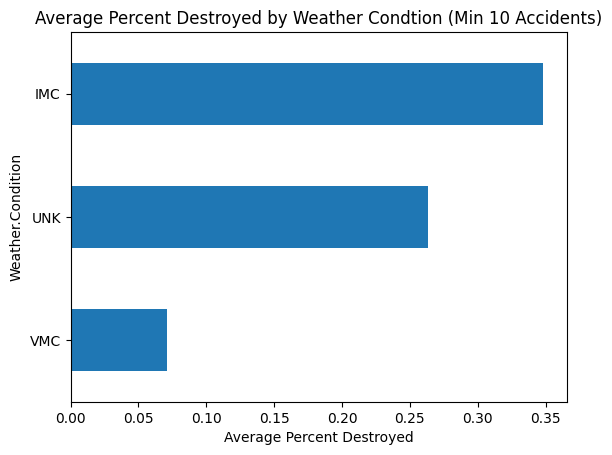

In [115]:
stats = data.groupby('Weather.Condition')['Destroyed'].agg(['mean', 'count'])
filtered_stats = stats[stats['count'] >= 10]
weather_results = filtered_stats['mean'].sort_values(ascending=True).head(10)
weather_results.plot.barh()
plt.title('Average Percent Destroyed by Weather Condtion (Min 10 Accidents)')
plt.xlabel('Average Percent Destroyed')

weather_results.describe()

As you can see there are only 3 weather categories with a lot of data. IMC or Instrument Meteorological Conditions, UNK or Unknown, and VMC or Visual Meteorological Conditions.

Leaving aside unknown weather, we can see a drastic difference between instrument meterological conditions and visual meterological conditions. There is almost a 30% higher mean for IMC over VMC for percent destruction, with a similar 35% higher mean for fatal/serious injury percent. 

Upon further investigation, IMC requires pilots to navigate using only instruments because the visibility is very poor and they can see little, wheras in VMC pilots can also use visual indicators for navigation. This now makes the data make a lot of sense because with poorer sighlines crashes could be more severe, increase chances of injury and the destruction of the plane. 